# YOLO11 Apple Disease Classification

In [ ]:
!gdown 1v4hyiDc2vNzGRPu76nNCOIlfADb9DsQe
!unrar x -o+ -y "/content/apple-classification.rar" /content/
!pip -q install ultralytics

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.2

In [ ]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "--upgrade", "--force-reinstall",
    "numpy==1.26.4",
    "pandas==2.2.2",
])

print("numpy & pandas reinstalled — NOW restart the runtime!")

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"]     = "offline"

import math, json, random, shutil, warnings
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from tqdm.auto import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
DEVICE: cuda


In [ ]:
SOURCE_ROOT = "/content/Apple Disease Dataset/Augmentation"
WORK_ROOT   = "/content/yolo11_cls_work"
SPLIT_ROOT  = f"{WORK_ROOT}/split_dataset"

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

MODEL_NAME  = "yolo11s-cls.pt"
IMG_SIZE    = 224
EPOCHS      = 30
BATCH_SIZE  = 64
LR0         = 1e-3
DROPOUT     = 0.15
PATIENCE    = 10
WORKERS     = 2

N_BOOTSTRAPS    = 2000
BOOTSTRAP_SEED  = 123
N_GRADCAM_IMAGES = 12
GRADCAM_ALPHA   = 0.42

os.makedirs(WORK_ROOT, exist_ok=True)
print("SOURCE_ROOT:", SOURCE_ROOT)
print("WORK_ROOT  :", WORK_ROOT)
print("SPLIT_ROOT :", SPLIT_ROOT)

SOURCE_ROOT: /content/Apple Disease Dataset/Augmentation
WORK_ROOT  : /content/yolo11_cls_work
SPLIT_ROOT : /content/yolo11_cls_work/split_dataset


In [ ]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def split_classification_dataset(source_root, split_root,
                                  train_ratio=0.7, val_ratio=0.15,
                                  test_ratio=0.15, seed=42):
    source_root = Path(source_root)
    split_root  = Path(split_root)

    assert source_root.exists(), f"Source folder not found: {source_root}"
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-8, "Ratios must sum to 1."

    if split_root.exists():
        shutil.rmtree(split_root)

    for split in ["train", "val", "test"]:
        (split_root / split).mkdir(parents=True, exist_ok=True)

    class_dirs = sorted([d for d in source_root.iterdir() if d.is_dir()], key=lambda x: x.name)
    assert len(class_dirs) > 1, "Need at least 2 class folders."

    rng  = random.Random(seed)
    rows = []

    for class_dir in class_dirs:
        images = sorted([p for p in class_dir.iterdir()
                         if p.is_file() and p.suffix.lower() in IMG_EXTS])
        if len(images) == 0:
            print(f"Skipping empty class folder: {class_dir.name}")
            continue

        rng.shuffle(images)
        n = len(images)

        n_train = max(1, int(round(n * train_ratio)))
        n_val   = max(1, int(round(n * val_ratio)))
        n_test  = n - n_train - n_val

        if n_test < 1:
            n_test = 1
            if n_train > n_val and n_train > 1:
                n_train -= 1
            elif n_val > 1:
                n_val -= 1

        while n_train + n_val + n_test > n:
            if n_train > 1:   n_train -= 1
            elif n_val > 1:   n_val   -= 1
            else:             n_test  -= 1

        train_imgs = images[:n_train]
        val_imgs   = images[n_train:n_train + n_val]
        test_imgs  = images[n_train + n_val:]

        for split_name, split_imgs in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            out_dir = split_root / split_name / class_dir.name
            out_dir.mkdir(parents=True, exist_ok=True)
            for src in split_imgs:
                shutil.copy2(src, out_dir / src.name)

        rows.append({"class": class_dir.name, "total": n,
                     "train": len(train_imgs), "val": len(val_imgs), "test": len(test_imgs)})

    return pd.DataFrame(rows)


split_df = split_classification_dataset(
    SOURCE_ROOT, SPLIT_ROOT,
    train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, seed=SEED
)
display(split_df)

,class,total,train,val,test
0,Anthracnose,1777,1244,267,266
1,Black Pox,1778,1245,267,266
2,Black Rot,1778,1245,267,266
3,Healthy,1778,1245,267,266
4,Powdery Mildew,1778,1245,267,266


In [ ]:
train_dir = Path(SPLIT_ROOT) / "train"
val_dir   = Path(SPLIT_ROOT) / "val"
test_dir  = Path(SPLIT_ROOT) / "test"

classes      = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

train_counts = {c: len(list((train_dir / c).glob("*"))) for c in classes}
val_counts   = {c: len(list((val_dir   / c).glob("*"))) for c in classes}
test_counts  = {c: len(list((test_dir  / c).glob("*"))) for c in classes}

stats_df = pd.DataFrame({
    "class": classes,
    "train": [train_counts[c] for c in classes],
    "val"  : [val_counts[c]   for c in classes],
    "test" : [test_counts[c]  for c in classes],
})
stats_df["total"] = stats_df[["train", "val", "test"]].sum(axis=1)
display(stats_df)
print("Classes:", classes)

,class,train,val,test,total
0,Anthracnose,1244,267,266,1777
1,Black Pox,1245,267,266,1778
2,Black Rot,1245,267,266,1778
3,Healthy,1245,267,266,1778
4,Powdery Mildew,1245,267,266,1778


Classes: ['Anthracnose', 'Black Pox', 'Black Rot', 'Healthy', 'Powdery Mildew']


In [ ]:
model = YOLO(MODEL_NAME)

train_results = model.train(
    data      = SPLIT_ROOT,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    project   = "yolo11_cls_runs",
    name      = "yolo11_cls_default",
    pretrained= True,
    optimizer = "AdamW",
    lr0       = LR0,
    dropout   = DROPOUT,
    patience  = PATIENCE,
    workers   = WORKERS,
    seed      = SEED,
    deterministic = True,
    verbose   = True,
    close_mosaic = 0,
    plots     = True,
)

save_dir = Path(model.trainer.save_dir)
print("Training finished. save_dir:", save_dir)

New https://pypi.org/project/ultralytics/8.4.38 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: task=classify, mode=train, model=yolo11s-cls.pt, data=/content/yolo11_cls_work/split_dataset, epochs=30, time=None, patience=10, batch=64, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=2, project=yolo11_cls_runs, name=yolo11_cls_default2, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=0, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.15, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_mask

train: Scanning /content/yolo11_cls_work/split_dataset/train... 6224 images, 0 corrupt: 100%|██████████| 6224/6224 [00:01<00:00, 3431.51it/s]


train: New cache created: /content/yolo11_cls_work/split_dataset/train.cache


val: Scanning /content/yolo11_cls_work/split_dataset/val... 1335 images, 0 corrupt: 100%|██████████| 1335/1335 [00:00<00:00, 3084.31it/s]

val: New cache created: /content/yolo11_cls_work/split_dataset/val.cache


...

      30/30      1.55G    0.06932         16        224: 100%|██████████| 98/98 [00:23<00:00,  4.15it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 11/11 [00:02<00:00,  4.34it/s]

                   all      0.969          1



30 epochs completed in 0.232 hours.
Optimizer stripped from yolo11_cls_runs/yolo11_cls_default2/weights/last.pt, 11.0MB
Optimizer stripped from yolo11_cls_runs/yolo11_cls_default2/weights/best.pt, 11.0MB

Validating yolo11_cls_runs/yolo11_cls_default2/weights/best.pt...
Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11s-cls summary (fused): 112 layers, 5,440,533 parameters, 0 gradients, 12.0 GFLOPs
train: /content/yolo11_cls_work/split_dataset/train... found 6224 images in 5 classes ✅ 
val: /content/yolo11_cls_work/split_dataset/val... found 1335 images in 5 classes ✅ 
test: /content/yolo11_cls_work/split_dataset/test... found 1330 images in 5 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 11/11 [00:02<00:00,  4.22it/s]


                   all      0.972          1
Speed: 0.1ms preprocess, 0.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to yolo11_cls_runs/yolo11_cls_default2
Results saved to yolo11_cls_runs/yolo11_cls_default2
Training finished. save_dir: yolo11_cls_runs/yolo11_cls_default2


In [ ]:
best_model_path = save_dir / "weights" / "best.pt"
last_model_path = save_dir / "weights" / "last.pt"

print("best.pt:", best_model_path)
print("last.pt:", last_model_path)
assert best_model_path.exists(), "best.pt not found — check save_dir"

best_model = YOLO(str(best_model_path))
print("Loaded best model.")

best.pt: yolo11_cls_runs/yolo11_cls_default2/weights/best.pt
last.pt: yolo11_cls_runs/yolo11_cls_default2/weights/last.pt
Loaded best model.


In [ ]:
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

test_dataset = datasets.ImageFolder(root=str(test_dir), transform=test_tfms)
test_loader  = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = WORKERS,
    pin_memory  = True,
)

assert test_dataset.classes == classes, "Class order mismatch between test set and training set!"
print(f"Test samples: {len(test_dataset)}")

Test samples: 1330


In [ ]:
def predict_probs_yolo_cls(yolo_model, dataloader, device="cuda"):
    net = yolo_model.model.to(device).eval()
    all_probs, all_preds, all_targets, all_paths = [], [], [], []
    sample_paths = [s[0] for s in dataloader.dataset.samples]
    ptr = 0

    with torch.no_grad():
        for imgs, targets in tqdm(dataloader, desc="Testing"):
            imgs   = imgs.to(device, non_blocking=True)
            logits = net(imgs)
            if isinstance(logits, (list, tuple)):
                logits = logits[0] if torch.is_tensor(logits[0]) else logits[1]

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            bs    = imgs.size(0)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.numpy())
            all_paths.extend(sample_paths[ptr:ptr + bs])
            ptr += bs

    return (
        np.concatenate(all_probs),
        np.concatenate(all_preds),
        np.concatenate(all_targets),
        all_paths,
    )


probs, y_pred, y_true, test_paths = predict_probs_yolo_cls(best_model, test_loader, device=DEVICE)

Testing:   0%|          | 0/21 [00:00<?, ?it/s]

In [ ]:
acc = accuracy_score(y_true, y_pred)
prec_macro,    rec_macro,    f1_macro,    _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print(f"Test Accuracy      : {acc:.4f}")
print(f"Macro Precision    : {prec_macro:.4f}")
print(f"Macro Recall       : {rec_macro:.4f}")
print(f"Macro F1           : {f1_macro:.4f}")
print(f"Weighted Precision : {prec_weighted:.4f}")
print(f"Weighted Recall    : {rec_weighted:.4f}")
print(f"Weighted F1        : {f1_weighted:.4f}")

report_txt  = classification_report(y_true, y_pred, target_names=classes, zero_division=0)
report_dict = classification_report(y_true, y_pred, target_names=classes, output_dict=True, zero_division=0)
report_df   = pd.DataFrame(report_dict).T
print(report_txt)
display(report_df)

Test Accuracy      : 0.9677
Macro Precision    : 0.9677
Macro Recall       : 0.9677
Macro F1           : 0.9676
Weighted Precision : 0.9677
Weighted Recall    : 0.9677
Weighted F1        : 0.9676
                precision    recall  f1-score   support

   Anthracnose       0.93      0.95      0.94       266
     Black Pox       0.99      1.00      0.99       266
     Black Rot       0.95      0.91      0.93       266
       Healthy       0.99      0.98      0.99       266
Powdery Mildew       0.99      0.99      0.99       266

      accuracy                           0.97      1330
     macro avg       0.97      0.97      0.97      1330
  weighted avg       0.97      0.97      0.97      1330



,precision,recall,f1-score,support
Anthracnose,0.926471,0.947368,0.936803,266.000000
Black Pox,0.988848,1.000000,0.994393,266.000000
Black Rot,0.945525,0.913534,0.929254,266.000000
Healthy,0.992424,0.984962,0.988679,266.000000
Powdery Mildew,0.985075,0.992481,0.988764,266.000000
accuracy,0.967669,0.967669,0.967669,0.967669
macro avg,0.967668,0.967669,0.967579,1330.000000
weighted avg,0.967668,0.967669,0.967579,1330.000000


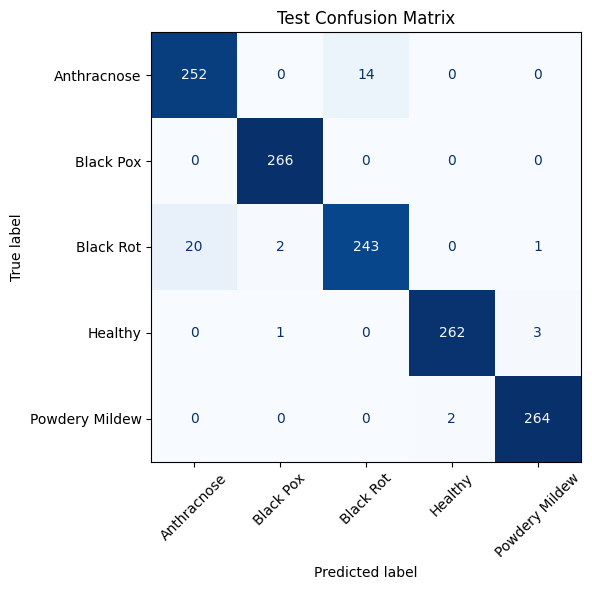

In [ ]:
cm  = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(8, len(classes) * 0.8), max(6, len(classes) * 0.8)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", values_format="d", colorbar=False)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.savefig(save_dir / "paper_confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.show()

In [ ]:
eval_dir = save_dir / "test_evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

report_df.to_csv(eval_dir / "classification_report.csv", index=True)
with open(eval_dir / "classification_report.txt", "w") as f:
    f.write(report_txt)

plt.figure(figsize=(max(8, len(classes) * 0.8), max(6, len(classes) * 0.8)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=plt.gca(), xticks_rotation=45, cmap="Blues", values_format="d", colorbar=False)
plt.title("Test Confusion Matrix")
plt.tight_layout()
plt.savefig(eval_dir / "confusion_matrix.png", dpi=220, bbox_inches="tight")
plt.close()

pred_df = pd.DataFrame({
    "path"      : test_paths,
    "true_idx"  : y_true,
    "pred_idx"  : y_pred,
    "true_label": [classes[i] for i in y_true],
    "pred_label": [classes[i] for i in y_pred],
    "confidence": probs.max(axis=1),
})
for i, cls_name in enumerate(classes):
    pred_df[f"prob_{cls_name}"] = probs[:, i]

pred_df.to_csv(eval_dir / "test_predictions.csv", index=False)
print("Saved test evaluation outputs to:", eval_dir)

Saved test evaluation outputs to: yolo11_cls_runs/yolo11_cls_default2/test_evaluation


Bootstrapping:   0%|          | 0/2000 [00:00<?, ?it/s]

,metric,point_estimate,mean_bootstrap,ci_lower_95,ci_upper_95,std_bootstrap
0,accuracy,0.967669,0.967474,0.957876,0.976692,0.004861
1,precision_macro,0.967668,0.967484,0.957653,0.976247,0.004809
2,recall_macro,0.967669,0.967526,0.957914,0.976261,0.004734
3,f1_macro,0.967579,0.967352,0.957604,0.976110,0.004802
4,precision_weighted,0.967668,0.967602,0.957961,0.976593,0.004835
5,recall_weighted,0.967669,0.967474,0.957876,0.976692,0.004861
6,f1_weighted,0.967579,0.967385,0.957574,0.976603,0.004888


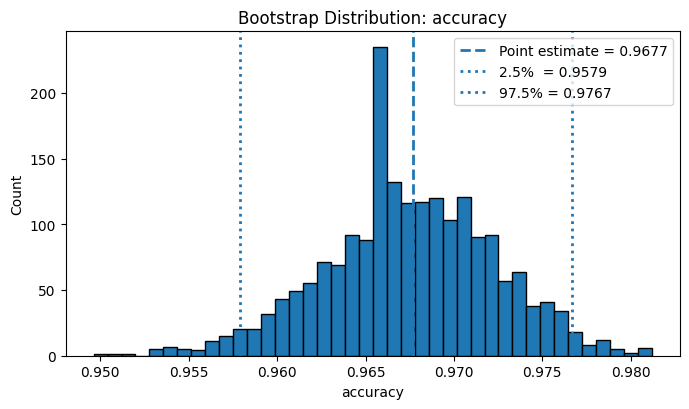

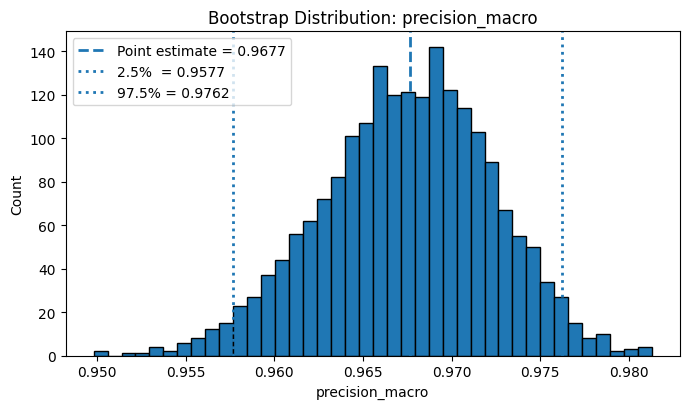

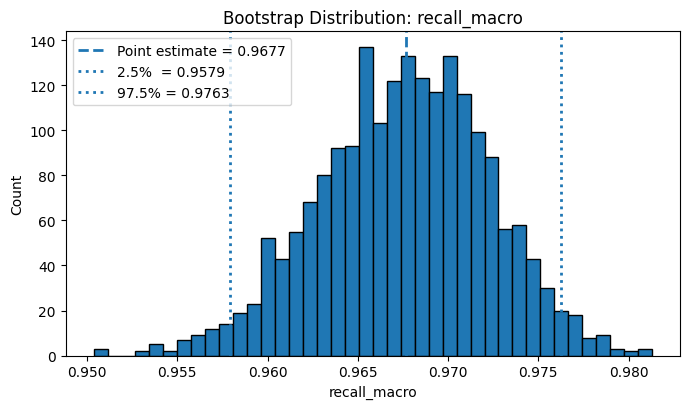

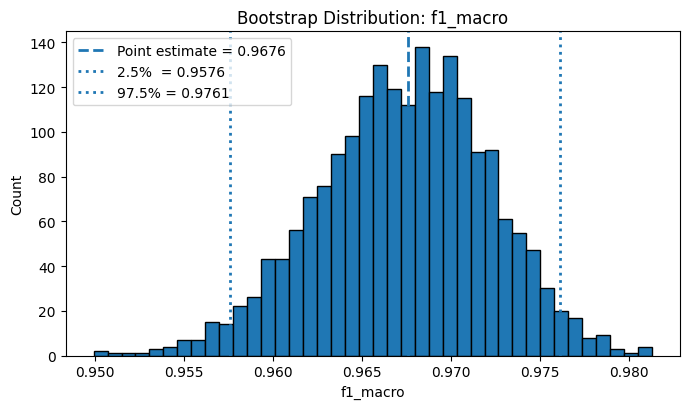

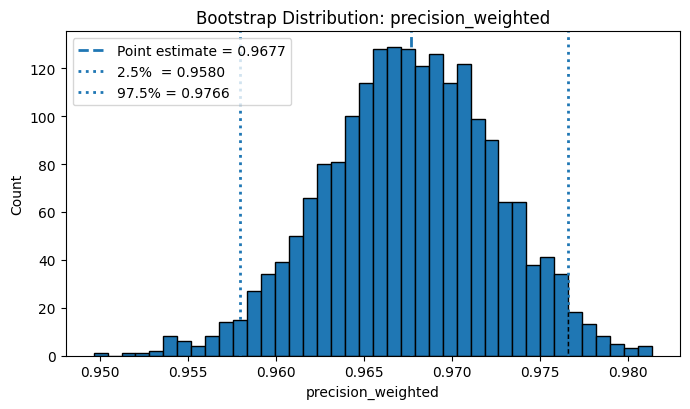

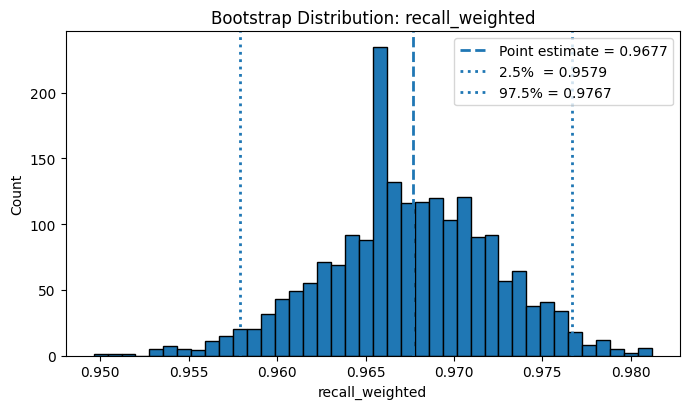

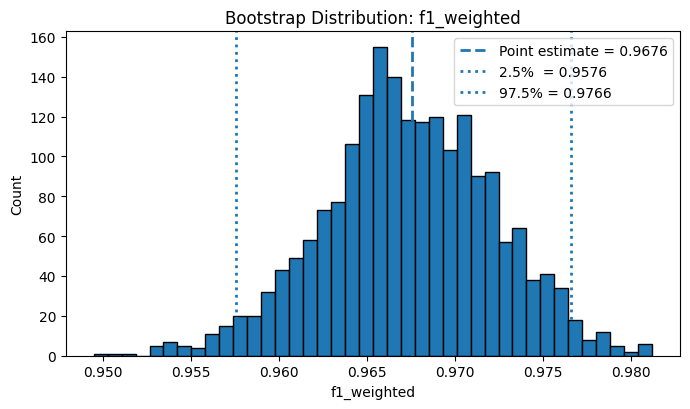

Saved bootstrap outputs to: yolo11_cls_runs/yolo11_cls_default2/bootstrap


In [ ]:
rng = np.random.default_rng(BOOTSTRAP_SEED)
n   = len(y_true)

def compute_metrics(y_t, y_p):
    acc_ = accuracy_score(y_t, y_p)
    p_m,  r_m,  f1_m,  _ = precision_recall_fscore_support(y_t, y_p, average="macro",    zero_division=0)
    p_w,  r_w,  f1_w,  _ = precision_recall_fscore_support(y_t, y_p, average="weighted", zero_division=0)
    return {"accuracy": acc_,
            "precision_macro": p_m, "recall_macro": r_m, "f1_macro": f1_m,
            "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f1_w}

point_metrics = compute_metrics(y_true, y_pred)

boot_metrics = []
for _ in tqdm(range(N_BOOTSTRAPS), desc="Bootstrapping"):
    idx = rng.integers(0, n, size=n)
    boot_metrics.append(compute_metrics(y_true[idx], y_pred[idx]))

boot_df = pd.DataFrame(boot_metrics)

summary_rows = []
for col in boot_df.columns:
    vals = boot_df[col].values
    summary_rows.append({
        "metric"         : col,
        "point_estimate" : point_metrics[col],
        "mean_bootstrap" : vals.mean(),
        "ci_lower_95"    : np.percentile(vals, 2.5),
        "ci_upper_95"    : np.percentile(vals, 97.5),
        "std_bootstrap"  : vals.std(ddof=1),
    })

bootstrap_summary_df = pd.DataFrame(summary_rows)
display(bootstrap_summary_df)

bootstrap_dir = save_dir / "bootstrap"
bootstrap_dir.mkdir(parents=True, exist_ok=True)

bootstrap_summary_df.to_csv(bootstrap_dir / "bootstrap_confidence_intervals.csv", index=False)
boot_df.to_csv(bootstrap_dir / "bootstrap_all_samples.csv", index=False)

with open(bootstrap_dir / "bootstrap_report.txt", "w") as f:
    f.write("Bootstrap Confidence Interval Report (95%)\n" + "=" * 60 + "\n\n")
    for _, row in bootstrap_summary_df.iterrows():
        f.write(f"{row['metric']}: point={row['point_estimate']:.4f}, "
                f"mean={row['mean_bootstrap']:.4f}, "
                f"95% CI=({row['ci_lower_95']:.4f}, {row['ci_upper_95']:.4f}), "
                f"std={row['std_bootstrap']:.4f}\n")

for metric in boot_df.columns:
    plt.figure(figsize=(7, 4.2))
    plt.hist(boot_df[metric], bins=40, edgecolor="black")
    pe = point_metrics[metric]
    lo = np.percentile(boot_df[metric], 2.5)
    hi = np.percentile(boot_df[metric], 97.5)
    plt.axvline(pe, linestyle="--", linewidth=2, label=f"Point estimate = {pe:.4f}")
    plt.axvline(lo, linestyle=":",  linewidth=2, label=f"2.5%  = {lo:.4f}")
    plt.axvline(hi, linestyle=":",  linewidth=2, label=f"97.5% = {hi:.4f}")
    plt.title(f"Bootstrap Distribution: {metric}")
    plt.xlabel(metric); plt.ylabel("Count"); plt.legend()
    plt.tight_layout()
    plt.savefig(bootstrap_dir / f"{metric}_bootstrap_hist.png", dpi=220, bbox_inches="tight")
    plt.show()

print("Saved bootstrap outputs to:", bootstrap_dir)

Grad-CAM target layer: model.10.conv.conv


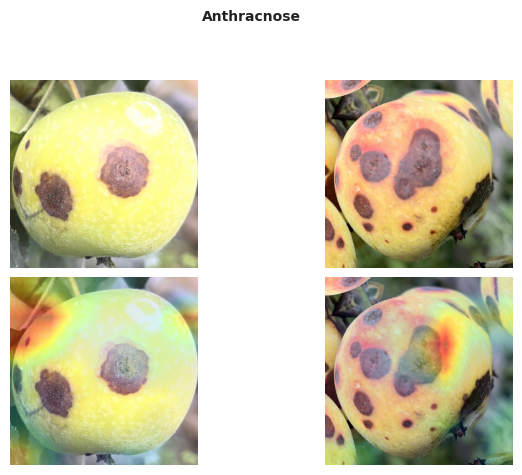

✓ Anthracnose


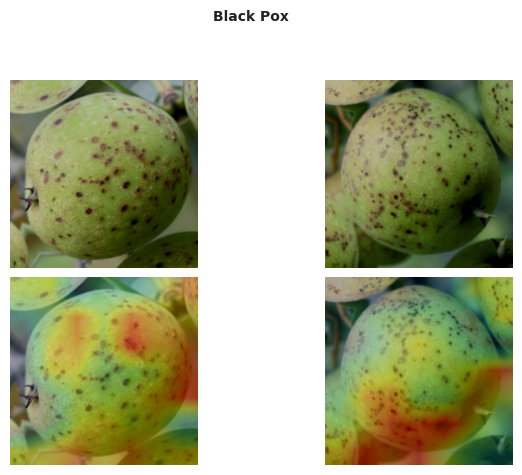

✓ Black Pox


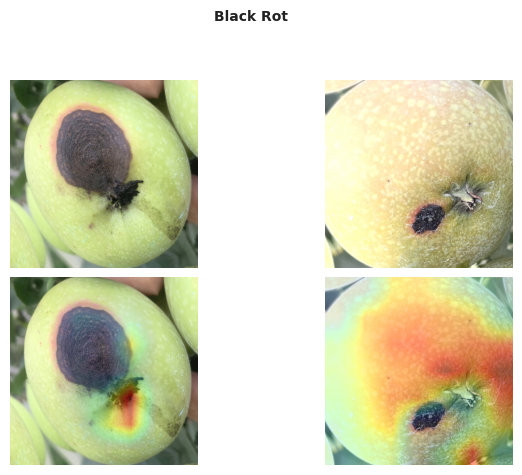

✓ Black Rot


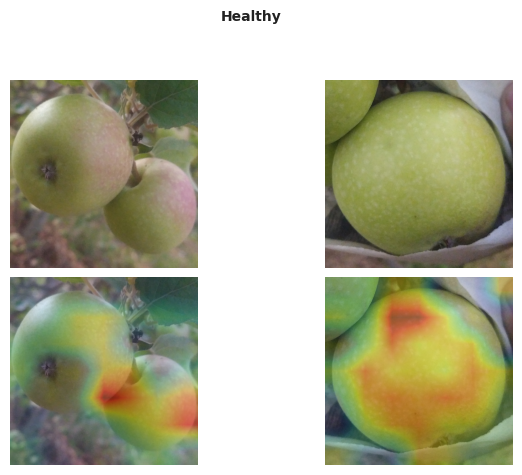

✓ Healthy


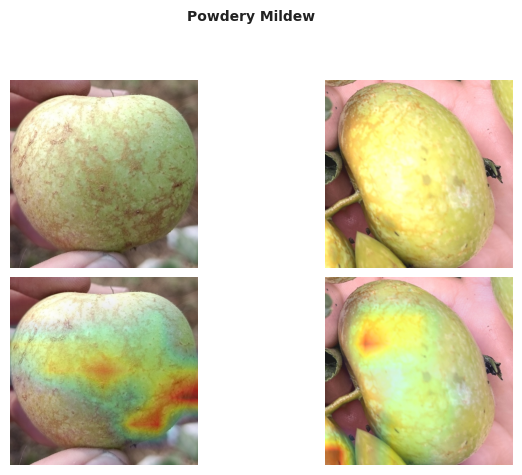

✓ Powdery Mildew


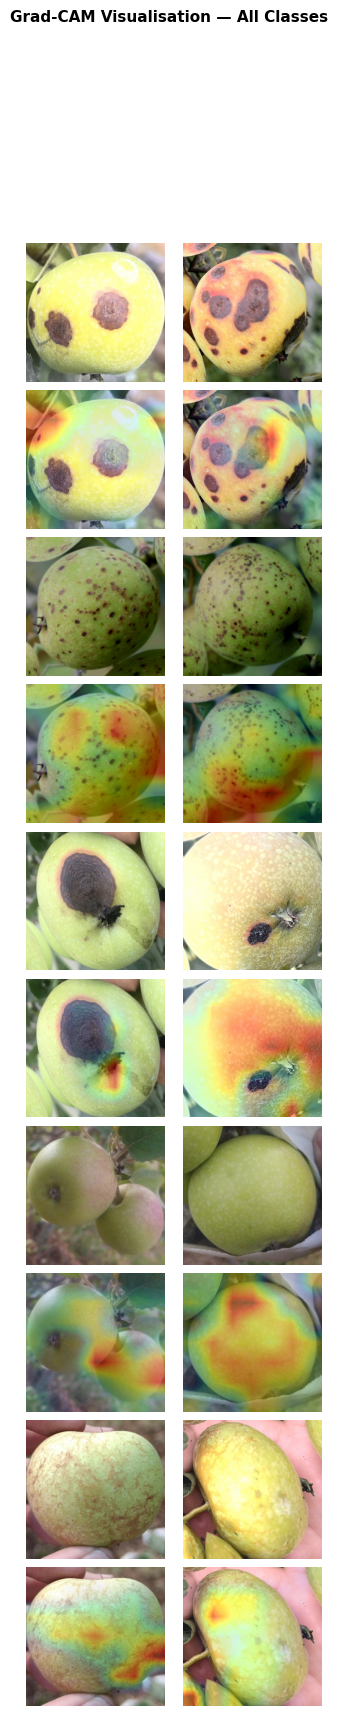


All outputs saved to: yolo11_cls_runs/yolo11_cls_default2/gradcam_paper
  • Per-class PDF+PNG : class_<name>.pdf / .png
  • Combined PDF+PNG  : all_classes_combined.pdf / .png  ← use in paper


In [ ]:
gradcam_dir = save_dir / "gradcam_paper"
gradcam_dir.mkdir(parents=True, exist_ok=True)

net = best_model.model.to(DEVICE).eval()

target_layer_name = "model.10.conv.conv"
target_layer      = dict(net.named_modules())[target_layer_name]
print("Grad-CAM target layer:", target_layer_name)

IMGS_PER_CLASS = 2      # 2 cols × 2 rows
NCOLS          = 2
ALPHA_MAX      = 0.50    # 0.35 = subtle  |  0.65 = vivid
CMAP           = "jet"   # try 'inferno' or 'plasma' for print


class GradCAM:
    def __init__(self, model, layer):
        self.model       = model
        self.layer       = layer
        self.activations = None
        self.gradients   = None
        h1 = layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach()))
        h2 = layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach()))
        self._hooks = [h1, h2]

    def __call__(self, x, class_idx=None):
        with torch.enable_grad():
            x = x.requires_grad_(True)
            self.model.zero_grad(set_to_none=True)
            out = self.model(x)
            if isinstance(out, (list, tuple)):
                out = out[0] if torch.is_tensor(out[0]) else out[1]
            if class_idx is None:
                class_idx = out.argmax(dim=1).item()
            out[:, class_idx].sum().backward(retain_graph=True)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(dim=1))[0].cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def preprocess_pil(img_pil, size=224):
    return transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
    ])(img_pil).unsqueeze(0)


def make_overlay(rgb_img, cam, alpha_max=0.50, cmap="jet"):
    h, w         = rgb_img.shape[:2]
    cam_r        = cv2.resize(cam, (w, h))
    rgba         = plt.get_cmap(cmap)(cam_r).copy()
    rgba[..., 3] = cam_r * alpha_max
    return rgba


def save_fig(fig, path_no_ext):
    for ext in ("pdf", "png"):
        fig.savefig(f"{path_no_ext}.{ext}",
                    dpi=300, bbox_inches="tight", facecolor="white")


gradcam = GradCAM(net, target_layer)

class_to_paths = {c: [] for c in classes}
for path, label_idx in test_dataset.samples:
    class_to_paths[idx_to_class[label_idx]].append(path)


all_class_data = []

for cls_name in classes:
    paths = class_to_paths[cls_name].copy()
    random.Random().shuffle(paths)
    selected_paths = paths[:IMGS_PER_CLASS]

    entries = []
    for path in selected_paths:
        img_pil      = Image.open(path).convert("RGB")
        input_tensor = preprocess_pil(img_pil, IMG_SIZE).to(DEVICE)

        with torch.no_grad():
            out = net(input_tensor)
            if isinstance(out, (list, tuple)):
                out = out[0] if torch.is_tensor(out[0]) else out[1]
            probs_    = torch.softmax(out, dim=1)
            pred_idx_ = probs_.argmax(dim=1).item()
            conf_     = probs_[0, pred_idx_].item()

        cam, _ = gradcam(input_tensor, class_idx=pred_idx_)
        rgb     = np.array(img_pil)
        overlay = make_overlay(rgb, cam, alpha_max=ALPHA_MAX, cmap=CMAP)

        entries.append({
            "rgb"       : rgb,
            "overlay"   : overlay,
            "pred_label": idx_to_class[pred_idx_],
            "conf"      : conf_,
            "correct"   : idx_to_class[pred_idx_] == cls_name,
        })

    all_class_data.append((cls_name, entries))

    fig, axes = plt.subplots(
        2, NCOLS,
        # figsize=(NCOLS * 2.0, 4.0),
        gridspec_kw={"hspace": 0.05, "wspace": 0.03}, figsize=(8, 5)
    )
    fig.patch.set_facecolor("white")

    for col, e in enumerate(entries):
        color = "#27ae60" if e["correct"] else "#c0392b"

        axes[0, col].imshow(e["rgb"])
        axes[0, col].axis("off")

        axes[1, col].imshow(e["rgb"])
        axes[1, col].imshow(e["overlay"])
        # axes[1, col].set_title(f"{e['conf']:.2f}", fontsize=8, color=color, pad=2)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=8, color="#444", labelpad=4)
    axes[1, 0].set_ylabel("Grad-CAM", fontsize=8, color="#444", labelpad=4)
    fig.suptitle(cls_name.replace("_", " "), fontsize=10,
                 fontweight="bold", y=1.02, color="#222")

    save_fig(fig, gradcam_dir / f"class_{cls_name}")
    plt.show()
    plt.close()
    print(f"✓ {cls_name}")


n_classes   = len(classes)
nrows_total = n_classes * 2

fig, axes = plt.subplots(
    nrows_total, NCOLS,
    figsize=(NCOLS * 2.0, n_classes * 3.8),
    gridspec_kw={"hspace": 0.06, "wspace": 0.03}
)
fig.patch.set_facecolor("white")

for cls_idx, (cls_name, entries) in enumerate(all_class_data):
    row_orig    = cls_idx * 2
    row_overlay = cls_idx * 2 + 1

    for col, e in enumerate(entries):
        color = "#27ae60" if e["correct"] else "#c0392b"

        axes[row_orig, col].imshow(e["rgb"])
        axes[row_orig, col].axis("off")

        axes[row_overlay, col].imshow(e["rgb"])
        axes[row_overlay, col].imshow(e["overlay"])
        # axes[row_overlay, col].set_title(f"{e['conf']:.2f}", fontsize=7, color=color, pad=2)
        axes[row_overlay, col].axis("off")

    axes[row_orig, 0].set_ylabel(
        cls_name.replace("_", "\n"),
        fontsize=7.5, fontweight="bold", color="#222",
        labelpad=5, rotation=0, ha="right", va="center"
    )

    if cls_idx < n_classes - 1:
        for col in range(NCOLS):
            for spine in axes[row_overlay, col].spines.values():
                spine.set_visible(False)
            axes[row_overlay, col].spines["bottom"].set_visible(True)
            axes[row_overlay, col].spines["bottom"].set_linewidth(0.6)
            axes[row_overlay, col].spines["bottom"].set_color("#cccccc")

plt.suptitle("Grad-CAM Visualisation — All Classes",
             fontsize=11, fontweight="bold", y=1.003)

save_fig(fig, gradcam_dir / "all_classes_combined")
plt.show()
plt.close()

print("\nAll outputs saved to:", gradcam_dir)
print("  • Per-class PDF+PNG : class_<name>.pdf / .png")
print("  • Combined PDF+PNG  : all_classes_combined.pdf / .png  ← use in paper")

In [ ]:
report_dir = save_dir / "final_report"
report_dir.mkdir(parents=True, exist_ok=True)

lines = [
    "YOLO11 Classification Report",
    "=" * 80, "",
    "DATA", "-" * 80,
    f"Source root : {SOURCE_ROOT}",
    f"Split root  : {SPLIT_ROOT}",
    f"Classes     : {classes}", "",
    "TRAINING", "-" * 80,
    f"Model       : {MODEL_NAME}",
    f"Image size  : {IMG_SIZE}",
    f"Epochs      : {EPOCHS}",
    f"Batch size  : {BATCH_SIZE}",
    f"Optimizer   : AdamW",
    f"Initial LR  : {LR0}",
    f"Dropout     : {DROPOUT}",
    f"Loss        : CrossEntropyLoss (default)", "",
    "TEST RESULTS", "-" * 80,
    f"Accuracy             : {acc:.6f}",
    f"Macro Precision      : {prec_macro:.6f}",
    f"Macro Recall         : {rec_macro:.6f}",
    f"Macro F1             : {f1_macro:.6f}",
    f"Weighted Precision   : {prec_weighted:.6f}",
    f"Weighted Recall      : {rec_weighted:.6f}",
    f"Weighted F1          : {f1_weighted:.6f}", "",
    "BOOTSTRAP 95% CI", "-" * 80,
]
for _, row in bootstrap_summary_df.iterrows():
    lines.append(f"{row['metric']}: {row['point_estimate']:.6f} [{row['ci_lower_95']:.6f}, {row['ci_upper_95']:.6f}]")

lines += ["", "OUTPUT DIRECTORIES", "-" * 80,
          f"Training dir  : {save_dir}",
          f"Evaluation dir: {eval_dir}",
          f"Bootstrap dir : {bootstrap_dir}",
          f"GradCAM dir   : {gradcam_dir}"]

final_report_text = "\n".join(lines)
print(final_report_text)

with open(report_dir / "final_report.txt", "w") as f:
    f.write(final_report_text)

summary_json = {
    "classes": classes,
    "config": {
        "model": MODEL_NAME, "imgsz": IMG_SIZE, "epochs": EPOCHS,
        "batch_size": BATCH_SIZE, "lr0": LR0, "dropout": DROPOUT,
        "loss": "CrossEntropyLoss (default)",
    },
    "test_metrics": {
        "accuracy": acc,
        "precision_macro": prec_macro, "recall_macro": rec_macro, "f1_macro": f1_macro,
        "precision_weighted": prec_weighted, "recall_weighted": rec_weighted, "f1_weighted": f1_weighted,
    },
    "bootstrap_confidence_intervals": bootstrap_summary_df.to_dict(orient="records"),
}
with open(report_dir / "final_report.json", "w") as f:
    json.dump(summary_json, f, indent=2)

print("Saved final report to:", report_dir)

YOLO11 Classification Report

DATA
--------------------------------------------------------------------------------
Source root : /content/Apple Disease Dataset/Augmentation
Split root  : /content/yolo11_cls_work/split_dataset
Classes     : ['Anthracnose', 'Black Pox', 'Black Rot', 'Healthy', 'Powdery Mildew']

TRAINING
--------------------------------------------------------------------------------
Model       : yolo11s-cls.pt
Image size  : 224
Epochs      : 2
Batch size  : 64
Optimizer   : AdamW
Initial LR  : 0.001
Dropout     : 0.15
Loss        : CrossEntropyLoss (default)

TEST RESULTS
--------------------------------------------------------------------------------
Accuracy             : 0.890226
Macro Precision      : 0.899782
Macro Recall         : 0.890226
Macro F1             : 0.890801
Weighted Precision   : 0.899782
Weighted Recall      : 0.890226
Weighted F1          : 0.890801

BOOTSTRAP 95% CI
--------------------------------------------------------------------------------